<center><h1>Bharadwaj_Sujendra_Giri_Prasad_Final_Project</h1></center>

Name: Sujendra Giri Prasad Bharadwaj  
<br>
Github Username: sgbharad-2305  
<br>
USC ID: 1296124475

## 1. Transfer Learning for Image Classification

The goal is to classify the supplied images with four ImageNet-pretrained convolutional networks. The convolutional backbones stay frozen, while a small regularized classification head learns the classes in this dataset.

> **Dataset note.** The handout text refers to nine categories, but the dataset supplied for the project defines five classes (`C1` through `C5`); the count in the write-up is a typo. The notebook infers the number of classes from the folders that are present rather than hard-coding it, so the code is correct for whatever the data contains.

The four required pretrained architectures are **ResNet50, ResNet101, EfficientNetB0, and VGG16**.

### Import packages

In [1]:
# If TensorFlow is not installed in the notebook environment, run this once and restart the kernel.
# %pip install -q "tensorflow>=2.16" scikit-learn seaborn pillow

# Keep the notebook output clean. These lines only silence cosmetic framework messages
# (TensorFlow C++ INFO logs, a distutils deprecation from TF's own import, AutoGraph source
# notes, and third-party deprecation notices); real errors are unaffected. The two env/filter
# lines must run before TensorFlow is imported, so they come first.
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hide TF INFO and WARNING C++ logs; keep ERROR/FATAL
warnings.filterwarnings("ignore")           # hide Python DeprecationWarning / UserWarning noise

import gc
import random
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision, regularizers

tf.get_logger().setLevel("ERROR")           # quiet the Python-side TensorFlow logger
tf.autograph.set_verbosity(0)               # silence "AutoGraph could not transform ..." notes

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# On Apple silicon the GPU is used through the tensorflow-metal plug-in, which requires
# Python <= 3.12; select the "MLDS Final Project (Metal GPU)" kernel to train on the GPU.
# Without it TensorFlow falls back to CPU and the same code still runs, only far slower.
GPU_DEVICES = tf.config.list_physical_devices("GPU")
ACCELERATOR = "GPU" if GPU_DEVICES else "CPU"
STRATEGY = tf.distribute.get_strategy()

# Float32 everywhere on purpose. Mixed float16 is a worthwhile speed-up on CUDA hardware,
# but the Metal backend has known numerical-stability problems with it, and a silently
# corrupted training run is far more costly here than the time it would save.
mixed_precision.set_global_policy("float32")

print("TensorFlow imported successfully")
print("Local Python:", sys.executable)
print("Local accelerator:", ACCELERATOR)
print("Available GPUs:", GPU_DEVICES)
print("Numeric precision policy:", mixed_precision.global_policy().name)

TensorFlow imported successfully
Local Python: /Users/sujendra/Desktop/MLDS_Final_Project/.venv-metal311/bin/python
Local accelerator: GPU
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Numeric precision policy: float32


In [2]:
# Keeping one seed in one place makes the validation sample and training run repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMAGE_SIZE = (224, 224)
# Larger batches keep the accelerator or CPU busier than the handout's conservative size of 5.
BATCH_SIZE = 32 if GPU_DEVICES else 16

# Epoch policy follows the course clarification: the loop must be allowed to run for at
# least 50 epochs so the search actually has a chance to find the best epoch, while the
# best epoch itself may occur earlier. MIN_EPOCHS therefore blocks early stopping until
# epoch 50, and restore_best_weights recovers the lowest-validation-loss epoch across the
# whole run. The handout prefers 100 epochs, so that is the ceiling.
EPOCHS = 100
MIN_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8

VALIDATION_FRACTION = 0.20
L2_STRENGTH = 1e-4
DROPOUT_RATE = 0.20

# VS Code usually starts in the project root; Jupyter may start in the notebook folder.
data_candidates = [Path("data"), Path("../data")]

DATA_DIR = next((folder.resolve() for folder in data_candidates if folder.is_dir()), None)

if DATA_DIR is None:
    searched = "\n".join(f"  - {folder}" for folder in data_candidates)
    raise FileNotFoundError(
        "The local dataset folder was not found.\n"
        "Select the Python (MLDS Final Project) kernel and run from either \n"
        "the project root or its notebook folder.\n"
        f"Locations checked:\n{searched}"
    )

ARTIFACT_DIR = DATA_DIR.parent / "artifacts" / "final_project"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Reading images from:", DATA_DIR.resolve())
print("Saving checkpoints and tables to:", ARTIFACT_DIR.resolve())
print(f"Epoch budget: up to {EPOCHS}, with early stopping disabled before epoch {MIN_EPOCHS}.")

Reading images from: /Users/sujendra/Desktop/MLDS_Final_Project/data
Saving checkpoints and tables to: /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project
Epoch budget: up to 100, with early stopping disabled before epoch 50.


### (a) Understand the supplied classification problem

In [3]:
def natural_key(path):
    # Sort embedded numbers numerically, so image 9 comes before image 10.
    pieces = re.split(r"(\d+)", Path(path).name.lower())
    return [int(piece) if piece.isdigit() else piece for piece in pieces]


image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
class_dirs = sorted([folder for folder in DATA_DIR.iterdir() if folder.is_dir()])
class_names = [folder.name for folder in class_dirs]
class_to_id = {name: index for index, name in enumerate(class_names)}

records = []
invalid_images = []
for folder in class_dirs:
    files = sorted(
        [path for path in folder.iterdir() if path.suffix.lower() in image_extensions],
        key=natural_key,
    )
    for path in files:
        # Decode each file once now so one damaged upload cannot stop a later epoch.
        try:
            with Image.open(path) as image:
                image.load()
                width, height = image.size
                color_mode = image.mode
        except (OSError, ValueError) as error:
            invalid_images.append({"path": str(path), "reason": str(error)})
            continue

        records.append(
            {
                "path": str(path),
                "class_name": folder.name,
                "class_id": class_to_id[folder.name],
                "width": width,
                "height": height,
                "mode": color_mode,
            }
        )

manifest = pd.DataFrame(records)
assert not manifest.empty, f"No images were found under {DATA_DIR.resolve()}"

if invalid_images:
    print(f"Skipped {len(invalid_images)} unreadable image file(s):")
    display(pd.DataFrame(invalid_images))
else:
    print("Image integrity check passed for every file.")

print(f"Classes found ({len(class_names)}):", class_names)
print("Total images:", f"{len(manifest):,}")
display(manifest.head())

Image integrity check passed for every file.
Classes found (5): ['C1', 'C2', 'C3', 'C4', 'C5']
Total images: 9,114


,path,class_name,class_id,width,height,mode
0,/Users/sujendra/Desktop/MLDS_Final_Project/dat...,C1,0,500,500,RGB
1,/Users/sujendra/Desktop/MLDS_Final_Project/dat...,C1,0,500,500,RGB
2,/Users/sujendra/Desktop/MLDS_Final_Project/dat...,C1,0,500,500,RGB
3,/Users/sujendra/Desktop/MLDS_Final_Project/dat...,C1,0,500,500,RGB
4,/Users/sujendra/Desktop/MLDS_Final_Project/dat...,C1,0,500,500,RGB


### (b) Data exploration and pre-processing

,class_name,image_count
0,C1,4404
1,C2,2334
2,C3,819
3,C4,818
4,C5,739


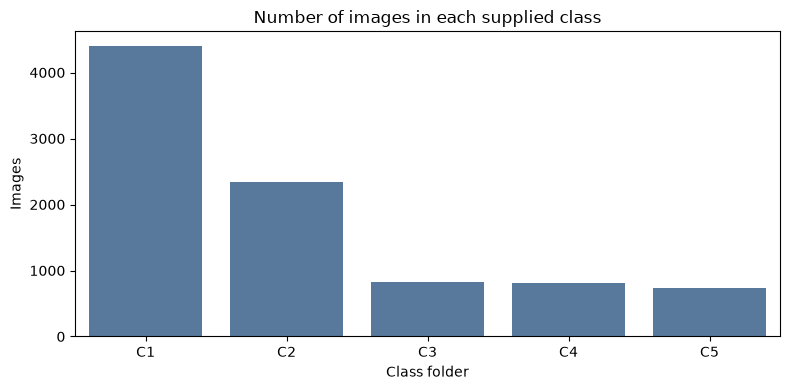

In [4]:
# Count each folder before splitting. This also makes the class imbalance easy to see.
class_counts = (
    manifest["class_name"]
    .value_counts()
    .reindex(class_names)
    .rename_axis("class_name")
    .reset_index(name="image_count")
)
display(class_counts)

plt.figure(figsize=(8, 4))
sns.barplot(data=class_counts, x="class_name", y="image_count", color="#4c78a8")
plt.title("Number of images in each supplied class")
plt.xlabel("Class folder")
plt.ylabel("Images")
plt.tight_layout()
plt.show()

In [5]:
# Width, height, and color mode were collected during the integrity check above.
image_properties = manifest[["width", "height", "mode"]].copy()
print("Image sizes:")
display(image_properties.value_counts(["width", "height"]).rename("count").reset_index())
print("Color modes:")
display(image_properties["mode"].value_counts().rename("count").to_frame())

print(
    "All source images have the same size." if image_properties[["width", "height"]].drop_duplicates().shape[0] == 1
    else "Source dimensions differ, so the input pipeline will resize every image."
)

Image sizes:


,width,height,count
0,500,500,9114


Color modes:


,count
mode,
RGB,9114


All source images have the same size.


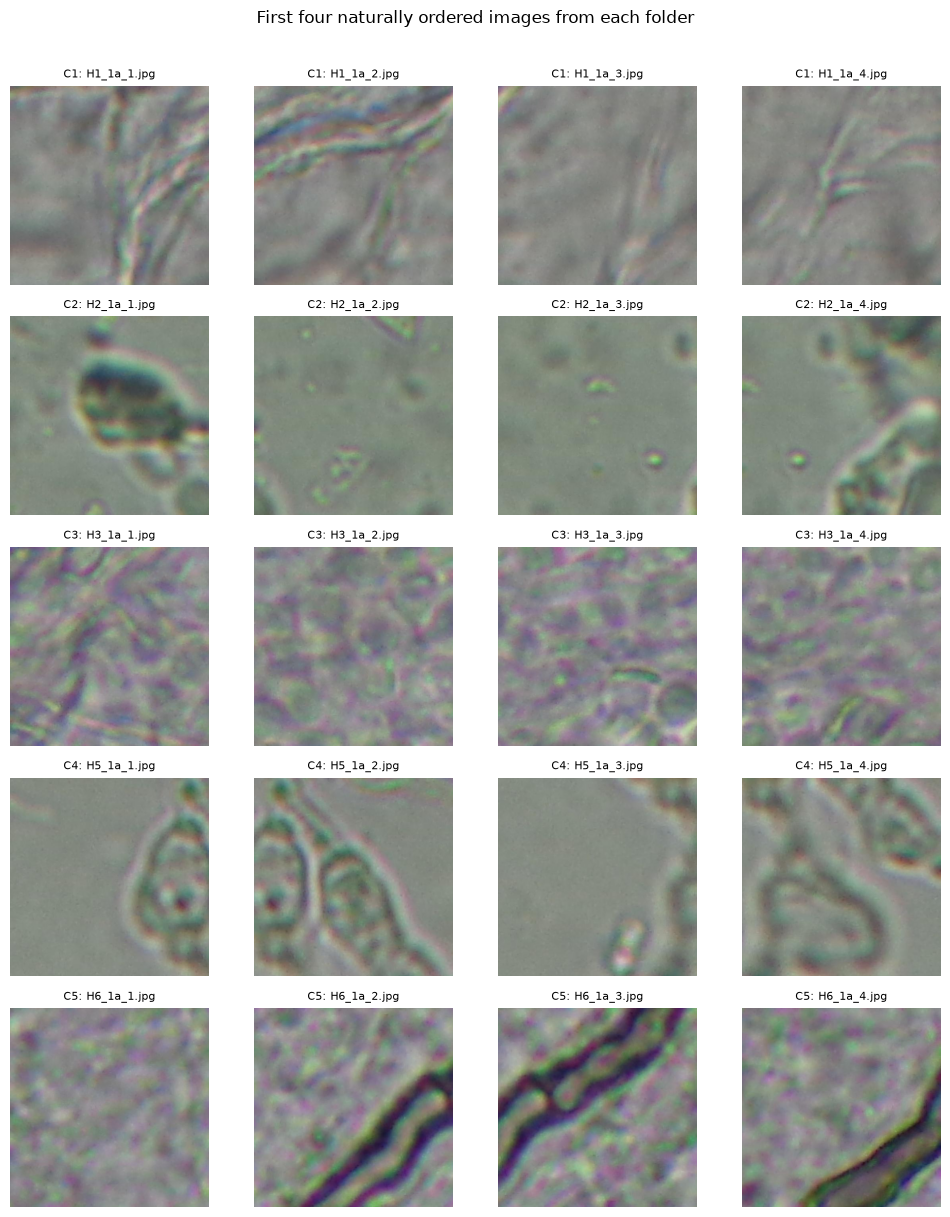

In [6]:
# A few examples help confirm that paths and labels line up before modeling.
fig, axes = plt.subplots(len(class_names), 4, figsize=(10, 2.4 * len(class_names)))
axes = np.atleast_2d(axes)

for row_index, class_name in enumerate(class_names):
    examples = manifest.loc[manifest["class_name"] == class_name].iloc[:4]
    for col_index, example in enumerate(examples.itertuples(index=False)):
        with Image.open(example.path) as image:
            axes[row_index, col_index].imshow(image.convert("RGB"))
        axes[row_index, col_index].set_title(f"{class_name}: {Path(example.path).name}", fontsize=8)
        axes[row_index, col_index].axis("off")

plt.suptitle("First four naturally ordered images from each folder", y=1.01)
plt.tight_layout()
plt.show()

#### (i) Make the training, validation, and test partitions

The handout says to take the first 80% of the images in each folder. The course clarified
that **either** a sorted first-80% split **or** a random 80% split is acceptable, provided it
is reasonable and applied consistently. This notebook uses the **random** split: within each
class the images are shuffled with a fixed seed and then partitioned, so the test set is a
random 20% of every class rather than the tail of the filename ordering.

The handout also asks for "a randomly selected subset of 20% of each class" as the validation
set. That 20% is measured against the full class and drawn from the 80% development pool, so
each class is partitioned **60% training / 20% validation / 20% test**, with validation and
test the same size. Every partition is stratified by class, and the seed makes the assignment
reproducible.

In [7]:
def make_classwise_splits(frame, validation_fraction=0.20, seed=42):
    """Random, class-wise 60/20/20 partition.

    The course confirmed that a random split is acceptable in place of the literal
    "first 80% of each folder". Shuffling within each class before partitioning keeps the
    class proportions of the original folders (the dataset is heavily imbalanced) while
    removing any dependence on filename ordering. The per-class seed makes the draw
    reproducible from run to run.
    """
    train_parts, validation_parts, test_parts = [], [], []

    for class_name in class_names:
        one_class = frame.loc[frame["class_name"] == class_name].copy()

        rng = np.random.default_rng(seed + class_to_id[class_name])
        shuffled = one_class.iloc[rng.permutation(len(one_class))].reset_index(drop=True)

        # 20% of the class is held out as test, a further 20% as validation.
        test_size = len(shuffled) - int(np.floor(0.80 * len(shuffled)))
        validation_size = int(np.ceil(validation_fraction * len(shuffled)))
        assert test_size + validation_size < len(shuffled), (
            f"{class_name}: nothing left to train on"
        )

        test_parts.append(shuffled.iloc[:test_size].copy())
        validation_parts.append(shuffled.iloc[test_size:test_size + validation_size].copy())
        train_parts.append(shuffled.iloc[test_size + validation_size:].copy())

    return (
        pd.concat(train_parts, ignore_index=True),
        pd.concat(validation_parts, ignore_index=True),
        pd.concat(test_parts, ignore_index=True),
    )


train_df, validation_df, test_df = make_classwise_splits(
    manifest, validation_fraction=VALIDATION_FRACTION, seed=SEED
)

split_counts = pd.concat(
    {
        "Training": train_df["class_name"].value_counts(),
        "Validation": validation_df["class_name"].value_counts(),
        "Test": test_df["class_name"].value_counts(),
    },
    axis=1,
).fillna(0).astype(int).reindex(class_names)

display(split_counts)
print("Split totals:", split_counts.sum().to_dict())

,Training,Validation,Test
class_name,,,
C1,2642,881,881
C2,1400,467,467
C3,491,164,164
C4,490,164,164
C5,443,148,148


Split totals: {'Training': 5466, 'Validation': 1824, 'Test': 1824}


In [8]:
# These checks guard against accidental overlap and confirm the requested class-wise split.
train_paths = set(train_df["path"])
validation_paths = set(validation_df["path"])
test_paths = set(test_df["path"])

assert train_paths.isdisjoint(validation_paths)
assert train_paths.isdisjoint(test_paths)
assert validation_paths.isdisjoint(test_paths)
assert len(train_df) + len(validation_df) + len(test_df) == len(manifest)

for class_name in class_names:
    total = (manifest["class_name"] == class_name).sum()
    expected_test = total - int(np.floor(0.80 * total))
    expected_validation = int(np.ceil(VALIDATION_FRACTION * total))
    assert (test_df["class_name"] == class_name).sum() == expected_test
    assert (validation_df["class_name"] == class_name).sum() == expected_validation

shares = (split_counts.T / split_counts.T.sum()).T.mul(100).round(1)
print("Per-class share of each partition (%):")
display(shares)
print(
    "The three partitions are disjoint and exhaustive. Within every class, a random 20% is "
    "the test set and a further random 20% is the validation set."
)

Per-class share of each partition (%):


,Training,Validation,Test
class_name,,,
C1,60.0,20.0,20.0
C2,60.0,20.0,20.0
C3,60.0,20.0,20.0
C4,59.9,20.0,20.0
C5,59.9,20.0,20.0


The three partitions are disjoint and exhaustive. Within every class, a random 20% is the test set and a further random 20% is the validation set.


#### (ii) Resize images and build input pipelines

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(class_names)


def decode_and_resize(path, class_id):
    image_bytes = tf.io.read_file(path)
    # decode_image handles every extension accepted by the manifest, not just JPEG.
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32)
    label = tf.one_hot(class_id, depth=NUM_CLASSES)
    return image, label


def make_dataset(frame, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (frame["path"].to_numpy(), frame["class_id"].to_numpy(dtype=np.int32))
    )
    if training:
        dataset = dataset.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(
        decode_and_resize,
        num_parallel_calls=AUTOTUNE,
        deterministic=not training,
    )
    dataset = dataset.batch(BATCH_SIZE)
    return dataset.prefetch(AUTOTUNE)


train_ds = make_dataset(train_df, training=True)
train_eval_ds = make_dataset(train_df, training=False)
validation_ds = make_dataset(validation_df, training=False)
test_ds = make_dataset(test_df, training=False)

one_batch_images, one_batch_labels = next(iter(train_ds))
print("Image batch shape:", one_batch_images.shape)
print("One-hot label batch shape:", one_batch_labels.shape)

Image batch shape: (32, 224, 224, 3)
One-hot label batch shape: (32, 5)


#### (iii) Training-only image augmentation

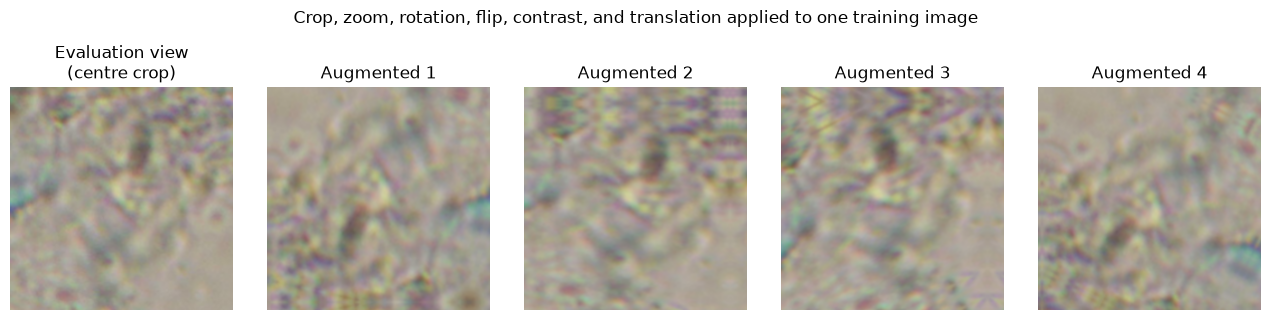

In [10]:
class MatchedCrop(layers.Layer):
    """Random crop while training, centre crop while evaluating.

    Keras 3's RandomCrop is an identity passthrough at inference time. Pairing it with a
    Resizing layer would therefore feed the backbone a 200px crop upscaled to 224 during
    training (content magnified by 224/200) but the untouched 224px frame during
    evaluation, so every reported score would be measured on a geometry the network never
    trained on. Cropping deterministically from the centre at inference keeps the scale
    identical across training, validation, and test while leaving the crop genuinely
    random during training.
    """

    def __init__(self, height, width, seed=None, **kwargs):
        super().__init__(**kwargs)
        self.height = height
        self.width = width
        self.random_crop = layers.RandomCrop(height, width, seed=seed)
        self.center_crop = layers.CenterCrop(height, width)

    def build(self, input_shape):
        # Build the two child crop layers explicitly. Neither has trainable weights, so this
        # only marks them built and changes no output; it silences a Keras "unbuilt state"
        # warning that would otherwise fire when this layer is used inside a Functional model.
        self.random_crop.build(input_shape)
        self.center_crop.build(input_shape)
        super().build(input_shape)

    def call(self, inputs, training=False):
        if training:
            return self.random_crop(inputs, training=True)
        return self.center_crop(inputs)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.height, self.width, input_shape[-1])


# Each requested transformation is represented here. The crop is matched across training
# and evaluation (see MatchedCrop); the remaining layers are random jitter that Keras
# disables automatically at inference, which is exactly what empirical regularization wants.
# This is a factory rather than a single shared object: the training loop calls
# clear_session() between models, and every model needs its own fresh layer instances.
def make_augmentation():
    return keras.Sequential(
        [
            MatchedCrop(200, 200, seed=SEED),
            layers.Resizing(*IMAGE_SIZE),
            layers.RandomZoom(height_factor=(-0.15, 0.15), width_factor=(-0.15, 0.15), seed=SEED),
            layers.RandomRotation(0.08, fill_mode="reflect", seed=SEED),
            layers.RandomFlip("horizontal_and_vertical", seed=SEED),
            layers.RandomContrast(0.15, seed=SEED),
            layers.RandomTranslation(0.08, 0.08, fill_mode="reflect", seed=SEED),
        ],
        name="training_augmentation",
    )


augmentation_preview = make_augmentation()

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
# training=False shows exactly what validation and test images look like going in.
evaluation_view = augmentation_preview(one_batch_images[:1], training=False)[0]
axes[0].imshow(tf.cast(tf.clip_by_value(evaluation_view, 0, 255), tf.uint8))
axes[0].set_title("Evaluation view\n(centre crop)")
axes[0].axis("off")

for index in range(1, 5):
    changed = augmentation_preview(one_batch_images[:1], training=True)[0]
    axes[index].imshow(tf.cast(tf.clip_by_value(changed, 0, 255), tf.uint8))
    axes[index].set_title(f"Augmented {index}")
    axes[index].axis("off")

plt.suptitle("Crop, zoom, rotation, flip, contrast, and translation applied to one training image", y=1.05)
plt.tight_layout()
plt.show()

### (c) Transfer learning

Each network begins with ImageNet weights. `include_top=False` removes the original ImageNet
classifier, and every backbone layer is frozen, so the penultimate-layer response is used purely
as a fixed feature vector.

Following the course clarification for part (c)(iii), the replacement head appends **both** new
layers and trains them together: a hidden `Dense` layer with ReLU activation, followed by batch
normalization, 20% dropout, and a final `Dense` softmax layer that produces the five-class
prediction. The L2 regularizer is applied **only to the hidden ReLU layer**, which holds the
large majority of the trainable parameters and is therefore the main source of overfitting; the
softmax output layer is left unregularized. Multinomial (categorical) cross-entropy and the Adam
optimizer are used for optimization.

**How augmentation coexists with a frozen feature extractor.** Part (c)(i) describes the
penultimate response as a fixed feature vector, while (c)(ii) asks for augmentation of the
training images. These are only in tension if the features are extracted once and cached.
They are not cached here: the augmentation layers sit *inside* the model, ahead of the
backbone, so every epoch re-augments each training image and pushes it through the frozen
base again. "Frozen" means the backbone's *weights* never receive gradient updates, not that
its *output* is constant. Each epoch therefore sees a different feature vector for the same
source image, which is exactly what makes the augmentation act as a regularizer.


In [11]:
# Store the four required backbones with their ImageNet preprocessing function and the name
# of the penultimate layer whose response is used as the feature vector.
#
# The handout writes "ResNet100", which is not a Keras architecture; ResNet101 is the model
# it refers to, and the course confirmed ResNet101 rather than ResNet101V2.
#
# ResNet50, ResNet101, and EfficientNetB0 all end in a global average pooling layer feeding
# their ImageNet classifier, so `include_top=False` plus GlobalAveragePooling2D reproduces
# their penultimate layer exactly; those entries carry None. VGG16 is different: its
# penultimate layer is the 4096-unit `fc2` dense layer, so the full network is loaded and
# cut there instead of pooling the last convolutional block.
MODEL_SPECS = {
    "ResNet50": (
        tf.keras.applications.ResNet50,
        tf.keras.applications.resnet50.preprocess_input,
        None,
    ),
    "ResNet101": (
        tf.keras.applications.ResNet101,
        tf.keras.applications.resnet.preprocess_input,
        None,
    ),
    "EfficientNetB0": (
        tf.keras.applications.EfficientNetB0,
        tf.keras.applications.efficientnet.preprocess_input,
        None,
    ),
    "VGG16": (
        tf.keras.applications.VGG16,
        tf.keras.applications.vgg16.preprocess_input,
        "fc2",
    ),
}


def _build_backbone(model_name):
    """Return the frozen feature extractor and whether its output still needs pooling."""
    constructor, _, penultimate_layer = MODEL_SPECS[model_name]

    if penultimate_layer is None:
        backbone = constructor(
            include_top=False,
            weights="imagenet",
            input_shape=(*IMAGE_SIZE, 3),
        )
        needs_pooling = True
    else:
        full_model = constructor(
            include_top=True,
            weights="imagenet",
            input_shape=(*IMAGE_SIZE, 3),
        )
        backbone = keras.Model(
            full_model.input,
            full_model.get_layer(penultimate_layer).output,
            name=f"{model_name.lower()}_through_{penultimate_layer}",
        )
        needs_pooling = False

    backbone.trainable = False
    return backbone, needs_pooling


def _build_transfer_model(model_name):
    _, preprocess_input, _ = MODEL_SPECS[model_name]
    backbone, needs_pooling = _build_backbone(model_name)

    inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="image")
    x = make_augmentation()(inputs)
    x = layers.Lambda(preprocess_input, name="imagenet_preprocessing")(x)
    x = backbone(x, training=False)
    if needs_pooling:
        x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    # Hidden ReLU layer. Per the course clarification the L2 penalty goes here only:
    # this layer holds most of the trainable parameters, so it drives the overfitting.
    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_STRENGTH),
        name="relu_classifier",
    )(x)
    x = layers.BatchNormalization(name="head_batch_normalization")(x)
    x = layers.Dropout(DROPOUT_RATE, seed=SEED, name="head_dropout")(x)
    # Softmax output layer, deliberately left unregularized.
    # dtype float32 keeps probabilities stable even when GPU mixed precision is active.
    outputs = layers.Dense(
        NUM_CLASSES, activation="softmax", dtype="float32", name="class_probabilities"
    )(x)

    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalCrossentropy(),
        metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")],
    )

    assert not backbone.trainable
    assert all(not layer.trainable for layer in backbone.layers)
    return model, backbone


def build_transfer_model(model_name):
    # Accelerator variables must be created and compiled inside its strategy scope.
    with STRATEGY.scope():
        return _build_transfer_model(model_name)

In [12]:
# Build one network of each feature-extraction style as a sanity check.
# Only the replacement head should be trainable.
for check_name in ("ResNet101", "VGG16"):
    check_model, check_backbone = build_transfer_model(check_name)
    trainable_count = sum(np.prod(v.shape) for v in check_model.trainable_weights)
    print(f"{check_name}:")
    print(f"  penultimate feature vector : {check_backbone.output.shape[-1]} values")
    print(f"  frozen backbone parameters : {check_backbone.count_params():,}")
    print(f"  trainable head parameters  : {trainable_count:,}")
    del check_model, check_backbone
    tf.keras.backend.clear_session()
    gc.collect()

ResNet101:
  penultimate feature vector : 2048 values
  frozen backbone parameters : 42,658,176
  trainable head parameters  : 526,341
VGG16:
  penultimate feature vector : 4096 values
  frozen backbone parameters : 134,260,544
  trainable head parameters  : 1,050,629


#### (i) Train for at least 50 epochs with early stopping

**Reading the curves: the training line is pessimistic by construction.** Keras reports
training loss and accuracy from the forward passes it makes *while learning*, which have
augmentation active, dropout active, and batch normalization using batch statistics.
Validation is measured with augmentation off, dropout off, and batch normalization using its
moving averages. The training curve is therefore computed on deliberately harder inputs than
the validation curve, and it can legitimately sit at or below the validation curve —
noticeably so for VGG16 here.

This is a measurement artifact, not leakage and not a split error. The `Training` row of the
metrics table below is *not* taken from these curves: it is computed in a separate pass over
the un-augmented training images in inference mode, on equal footing with validation and test.
Measured that way every model scores higher on training than on validation, as expected.


In [13]:
def safe_name_for(model_name):
    return re.sub(r"[^A-Za-z0-9]+", "_", model_name).strip("_").lower()


def make_callbacks(model_name):
    checkpoint_path = ARTIFACT_DIR / f"{safe_name_for(model_name)}.weights.h5"
    return [
        # start_from_epoch holds early stopping off until MIN_EPOCHS, so every network
        # is allowed the full 50-epoch search the course requires. restore_best_weights
        # then recovers the lowest-validation-loss epoch from the entire run, which may
        # well be earlier than epoch 50.
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            start_from_epoch=MIN_EPOCHS,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.3,
            patience=4,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


# Takes a DataFrame so the same plot is produced whether the history was just computed
# or reloaded from disk on a resumed run.
def plot_learning_curves(history_frame, model_name):
    best_epoch = int(history_frame["val_loss"].idxmin() + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_frame.index + 1, history_frame["loss"], label="Training loss")
    axes[0].plot(history_frame.index + 1, history_frame["val_loss"], label="Validation loss")
    axes[0].axvline(best_epoch, color="gray", linestyle="--", alpha=0.7, label=f"Best epoch: {best_epoch}")
    axes[0].set(title=f"{model_name}: cross-entropy error", xlabel="Epoch", ylabel="Loss")
    axes[0].legend()

    axes[1].plot(history_frame.index + 1, history_frame["accuracy"], label="Training accuracy")
    axes[1].plot(history_frame.index + 1, history_frame["val_accuracy"], label="Validation accuracy")
    axes[1].set(title=f"{model_name}: accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return best_epoch

#### (ii) Define multiclass evaluation metrics

In [14]:
def score_probabilities(y_true_one_hot, probabilities):
    true_ids = np.argmax(y_true_one_hot, axis=1)
    predicted_ids = np.argmax(probabilities, axis=1)

    return {
        "Accuracy": accuracy_score(true_ids, predicted_ids),
        "Precision": precision_score(true_ids, predicted_ids, average="macro", zero_division=0),
        "Recall": recall_score(true_ids, predicted_ids, average="macro", zero_division=0),
        "AUC": roc_auc_score(y_true_one_hot, probabilities, average="macro", multi_class="ovr"),
        "F1": f1_score(true_ids, predicted_ids, average="macro", zero_division=0),
    }


def predict_and_score(model, dataset, split_name):
    # Evaluation datasets are built with shuffling off and deterministic=True, so the label
    # order below lines up with the prediction order from a single predict() call.
    probabilities = model.predict(dataset, verbose=0)
    y_true = np.concatenate([labels.numpy() for _, labels in dataset], axis=0)
    assert len(probabilities) == len(y_true), "prediction/label misalignment"
    scores = score_probabilities(y_true, probabilities)
    scores["Split"] = split_name
    return scores, y_true, probabilities

#### (iii) Fit and evaluate ResNet50, ResNet101, EfficientNetB0, and VGG16


Training ResNet50
Epoch 1/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.6261 - loss: 1.0799
Epoch 1: val_loss improved from None to 0.78786, saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/resnet50.weights.h5

Epoch 1: finished saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/resnet50.weights.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 94s 526ms/step - accuracy: 0.6261 - loss: 1.0799 - val_accuracy: 0.7292 - val_loss: 0.7879 - learning_rate: 0.0010
Epoch 2/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.6989 - loss: 0.8041
Epoch 2: val_loss improved from 0.78786 to 0.73738, saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/resnet50.weights.h5

Epoch 2: finished saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/resnet50.weights.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 84s 490ms/step - accuracy: 0.6989 - loss: 0.8041 - val_accuracy: 0.7407 - val_l

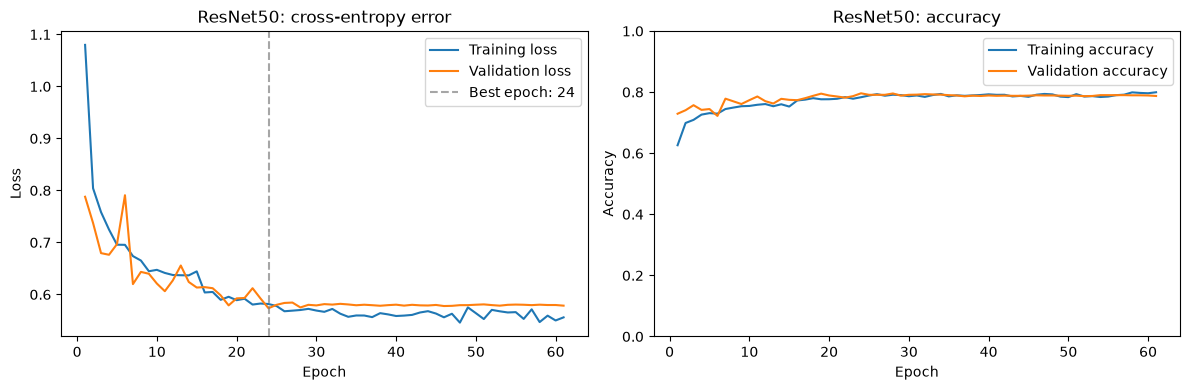

ResNet50: ran 61 epochs, lowest validation loss at epoch 24 (0.5735); those weights were restored.

Training ResNet101
Epoch 1/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.6359 - loss: 1.0767
Epoch 1: val_loss improved from None to 0.90658, saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/resnet101.weights.h5

Epoch 1: finished saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/resnet101.weights.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 93s 514ms/step - accuracy: 0.6359 - loss: 1.0767 - val_accuracy: 0.7050 - val_loss: 0.9066 - learning_rate: 0.0010
Epoch 2/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.7080 - loss: 0.8120
Epoch 2: val_loss improved from 0.90658 to 0.78112, saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/resnet101.weights.h5

Epoch 2: finished saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/resnet101.weights.h5
171/

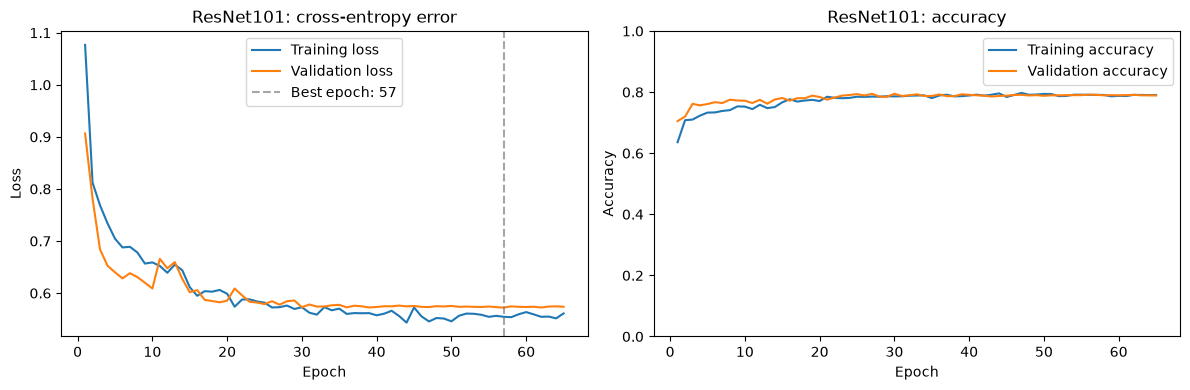

ResNet101: ran 65 epochs, lowest validation loss at epoch 57 (0.5721); those weights were restored.

Training EfficientNetB0
Epoch 1/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6068 - loss: 1.1178
Epoch 1: val_loss improved from None to 0.78962, saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/efficientnetb0.weights.h5

Epoch 1: finished saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/efficientnetb0.weights.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 48s 254ms/step - accuracy: 0.6068 - loss: 1.1178 - val_accuracy: 0.6996 - val_loss: 0.7896 - learning_rate: 0.0010
Epoch 2/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6720 - loss: 0.8737
Epoch 2: val_loss improved from 0.78962 to 0.77454, saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/efficientnetb0.weights.h5

Epoch 2: finished saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/effi

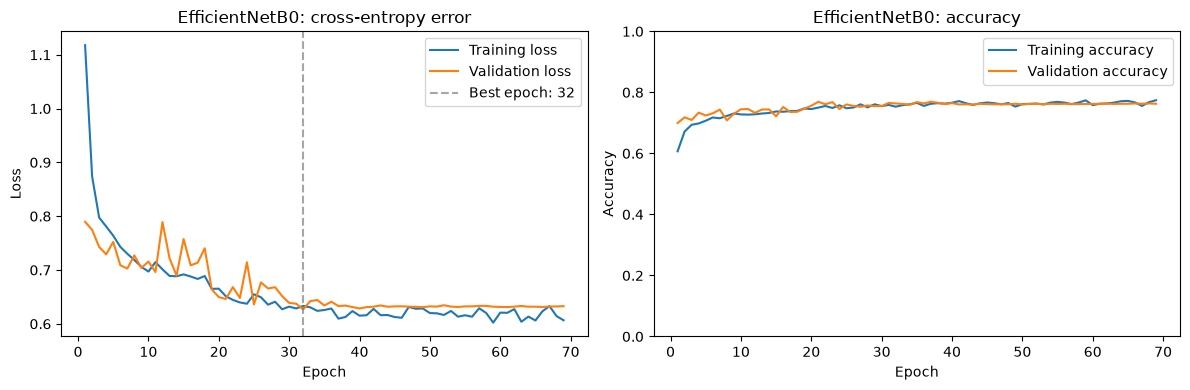

EfficientNetB0: ran 69 epochs, lowest validation loss at epoch 32 (0.6268); those weights were restored.

Training VGG16
Epoch 1/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.5864 - loss: 1.1572
Epoch 1: val_loss improved from None to 1.03231, saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/vgg16.weights.h5

Epoch 1: finished saving model to /Users/sujendra/Desktop/MLDS_Final_Project/artifacts/final_project/vgg16.weights.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 74s 426ms/step - accuracy: 0.5864 - loss: 1.1572 - val_accuracy: 0.6245 - val_loss: 1.0323 - learning_rate: 0.0010
Epoch 2/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.6332 - loss: 0.9831
Epoch 2: val_loss did not improve from 1.03231
171/171 ━━━━━━━━━━━━━━━━━━━━ 75s 442ms/step - accuracy: 0.6332 - loss: 0.9831 - val_accuracy: 0.6245 - val_loss: 1.1198 - learning_rate: 0.0010
Epoch 3/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.6293 - loss: 0.9659
Epoch 3: 

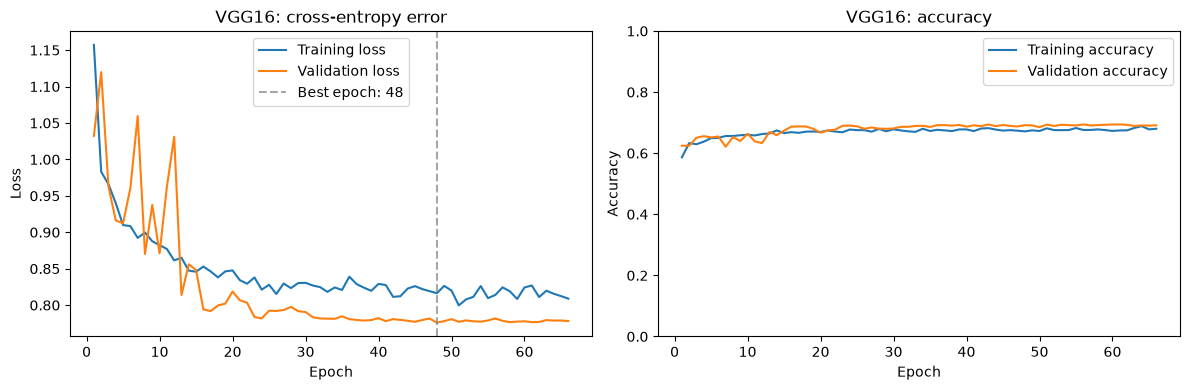

VGG16: ran 66 epochs, lowest validation loss at epoch 48 (0.7760); those weights were restored.


,Model,Split,Best epoch,Accuracy,Precision,Recall,AUC,F1
0,ResNet50,Training,24,0.8183,0.8806,0.8198,0.9594,0.8372
1,ResNet50,Validation,24,0.7873,0.8398,0.7787,0.9434,0.7961
2,ResNet50,Test,24,0.7971,0.8569,0.7958,0.9484,0.8119
3,ResNet101,Training,57,0.8128,0.8690,0.8135,0.9585,0.8318
4,ResNet101,Validation,57,0.7911,0.8384,0.7717,0.9454,0.7943
5,ResNet101,Test,57,0.7867,0.8400,0.7909,0.9474,0.8018
6,EfficientNetB0,Training,32,0.7836,0.8539,0.7679,0.9469,0.8013
7,EfficientNetB0,Validation,32,0.7626,0.8370,0.7314,0.9331,0.7694
8,EfficientNetB0,Test,32,0.7637,0.8284,0.7438,0.9342,0.7763
9,VGG16,Training,48,0.6978,0.7734,0.6283,0.8959,0.6628


In [15]:
# The handout requires all four pretrained backbones, so every entry in MODEL_SPECS is trained.
MODELS_TO_RUN = list(MODEL_SPECS)

# Four frozen-backbone networks take many hours on CPU. Each model writes its history,
# metrics, and confusion matrix as soon as it finishes, and a finished model is reloaded
# instead of retrained. An interrupted kernel therefore resumes where it stopped: just
# re-run this cell. To force a clean run, delete the *_scores.csv files in ARTIFACT_DIR.
all_scores = []
best_epochs = {}
test_confusion_matrices = {}

for model_name in MODELS_TO_RUN:
    safe_name = safe_name_for(model_name)
    history_path = ARTIFACT_DIR / f"{safe_name}_history.csv"
    scores_path = ARTIFACT_DIR / f"{safe_name}_scores.csv"
    confusion_path = ARTIFACT_DIR / f"{safe_name}_test_confusion.csv"

    print("\n" + "=" * 90)

    if scores_path.exists() and history_path.exists() and confusion_path.exists():
        print(f"{model_name}: reusing results already saved in {ARTIFACT_DIR.name}")
        print("=" * 90)
        history_frame = pd.read_csv(history_path)
        model_scores = pd.read_csv(scores_path)
        confusion = pd.read_csv(confusion_path, index_col=0).to_numpy()
    else:
        print("Training", model_name)
        print("=" * 90)

        tf.keras.backend.clear_session()
        gc.collect()
        model, backbone = build_transfer_model(model_name)

        history = model.fit(
            train_ds,
            validation_data=validation_ds,
            epochs=EPOCHS,
            callbacks=make_callbacks(model_name),
            # The tf.data pipeline already shuffles; this silences a redundant Keras warning.
            shuffle=False,
            verbose=1,
        )
        history_frame = pd.DataFrame(history.history)

        rows = []
        for split_name, dataset in (
            ("Training", train_eval_ds),
            ("Validation", validation_ds),
            ("Test", test_ds),
        ):
            scores, y_true, probabilities = predict_and_score(model, dataset, split_name)
            scores["Model"] = model_name
            rows.append(scores)

            if split_name == "Test":
                confusion = confusion_matrix(
                    np.argmax(y_true, axis=1),
                    np.argmax(probabilities, axis=1),
                    labels=np.arange(NUM_CLASSES),
                )

        model_scores = pd.DataFrame(rows)

        history_frame.to_csv(history_path, index=False)
        model_scores.to_csv(scores_path, index=False)
        pd.DataFrame(confusion, index=class_names, columns=class_names).to_csv(confusion_path)

        del model, backbone, history
        tf.keras.backend.clear_session()
        gc.collect()

    best_epoch = plot_learning_curves(history_frame, model_name)
    best_epochs[model_name] = best_epoch
    print(
        f"{model_name}: ran {len(history_frame)} epochs, "
        f"lowest validation loss at epoch {best_epoch} "
        f"({history_frame['val_loss'].min():.4f}); those weights were restored."
    )
    model_scores["Best epoch"] = best_epoch
    all_scores.extend(model_scores.to_dict("records"))
    test_confusion_matrices[model_name] = confusion

results = pd.DataFrame(all_scores)
results = results[["Model", "Split", "Best epoch", "Accuracy", "Precision", "Recall", "AUC", "F1"]]
results.to_csv(ARTIFACT_DIR / "all_model_metrics.csv", index=False)
display(results.round(4))

#### (iv) Compare the four models

Precision                      Recall                     \
Split           Training Validation    Test Training Validation    Test   
Model                                                                     
ResNet50          0.8806     0.8398  0.8569   0.8198     0.7787  0.7958   
ResNet101         0.8690     0.8384  0.8400   0.8135     0.7717  0.7909   
EfficientNetB0    0.8539     0.8370  0.8284   0.7679     0.7314  0.7438   
VGG16             0.7734     0.7405  0.7584   0.6283     0.6118  0.6208   

                    AUC                          F1                     
Split          Training Validation    Test Training Validation    Test  
Model                                                                   
ResNet50         0.9594     0.9434  0.9484   0.8372     0.7961  0.8119  
ResNet101        0.9585     0.9454  0.9474   0.8318     0.7943  0.8018  
EfficientNetB0   0.9469     0.9331  0.9342   0.8013     0.7694  0.7763  
VGG16            0.8959     0.8902  0.8917   0.6628     0.6410  0.6505

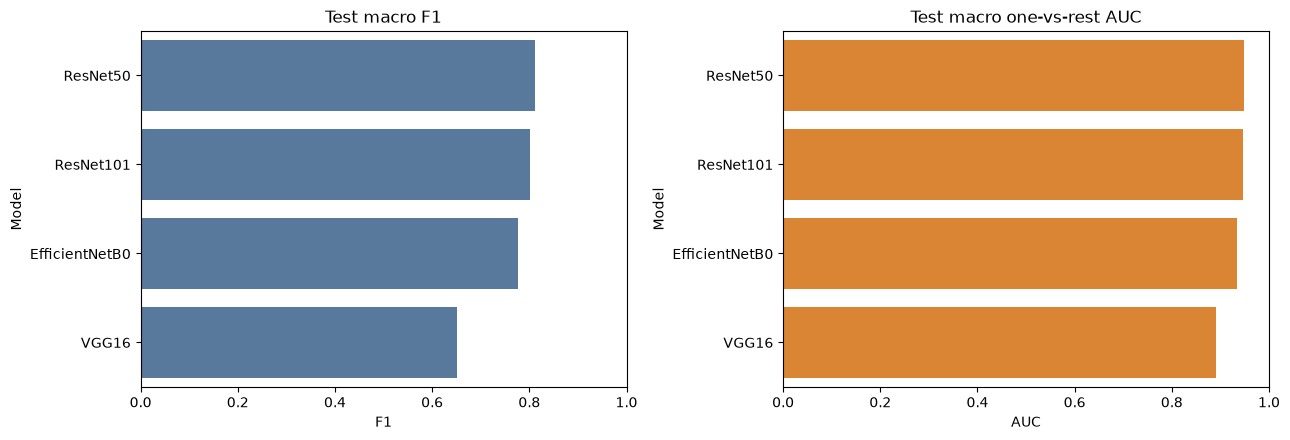

In [16]:
# This table reports every metric requested in the handout for all three partitions.
comparison = (
    results.pivot(index="Model", columns="Split", values=["Precision", "Recall", "AUC", "F1"])
    .reindex(MODELS_TO_RUN)
    .reindex(columns=["Training", "Validation", "Test"], level="Split")
)
display(comparison.round(4))

test_results = (
    results.loc[results["Split"] == "Test"]
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=test_results, x="F1", y="Model", color="#4c78a8", ax=axes[0])
axes[0].set_xlim(0, 1)
axes[0].set_title("Test macro F1")

sns.barplot(data=test_results, x="AUC", y="Model", color="#f58518", ax=axes[1])
axes[1].set_xlim(0, 1)
axes[1].set_title("Test macro one-vs-rest AUC")
plt.tight_layout()
plt.show()

In [17]:
# (v) Does one model clearly outperform the others?
# Macro F1 is the ranking metric because it weights every class equally on imbalanced folders.
CLEAR_WIN_MARGIN = 0.05

print("Test-set ranking by macro F1")
print("-" * 60)
for rank, row in enumerate(test_results.itertuples(index=False), start=1):
    print(
        f"{rank}. {row.Model:<16} F1={row.F1:.4f}  AUC={row.AUC:.4f}  "
        f"Precision={row.Precision:.4f}  Recall={row.Recall:.4f}"
    )

winner = test_results.iloc[0]
runner_up = test_results.iloc[1]
f1_margin = winner["F1"] - runner_up["F1"]

print("-" * 60)
print(f"Best model: {winner['Model']} (macro F1 {winner['F1']:.4f}, AUC {winner['AUC']:.4f})")
print(f"Margin over {runner_up['Model']}: {f1_margin:.4f} macro F1")

if f1_margin >= CLEAR_WIN_MARGIN:
    print(
        f"\nThis is a clear win: {winner['Model']} leads the next best model by more than "
        f"{CLEAR_WIN_MARGIN:.2f} macro F1."
    )
else:
    print(
        f"\nNo model clearly outperforms the others: the top two are within "
        f"{CLEAR_WIN_MARGIN:.2f} macro F1 of each other, which is inside the variation "
        "expected from a single training run with random augmentation."
    )

Test-set ranking by macro F1
------------------------------------------------------------
1. ResNet50         F1=0.8119  AUC=0.9484  Precision=0.8569  Recall=0.7958
2. ResNet101        F1=0.8018  AUC=0.9474  Precision=0.8400  Recall=0.7909
3. EfficientNetB0   F1=0.7763  AUC=0.9342  Precision=0.8284  Recall=0.7438
4. VGG16            F1=0.6505  AUC=0.8917  Precision=0.7584  Recall=0.6208
------------------------------------------------------------
Best model: ResNet50 (macro F1 0.8119, AUC 0.9484)
Margin over ResNet101: 0.0101 macro F1

No model clearly outperforms the others: the top two are within 0.05 macro F1 of each other, which is inside the variation expected from a single training run with random augmentation.


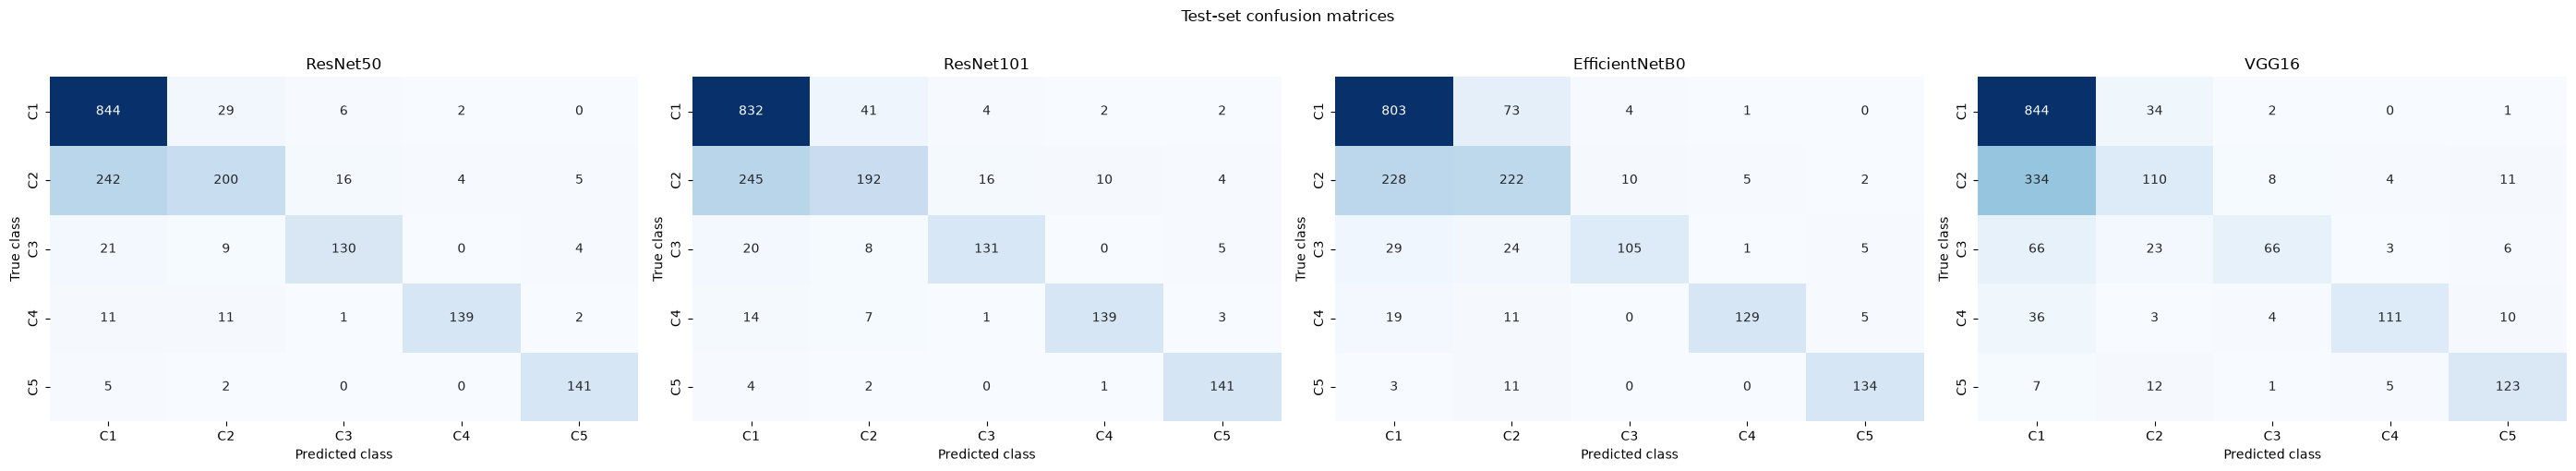

In [18]:
# Confusion matrices show which class pairs are responsible for the remaining errors.
fig, axes = plt.subplots(1, len(MODELS_TO_RUN), figsize=(7 * len(MODELS_TO_RUN), 5))
axes = np.atleast_1d(axes)
for axis, model_name in zip(axes, MODELS_TO_RUN):
    sns.heatmap(
        test_confusion_matrices[model_name],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        ax=axis,
    )
    axis.set_title(model_name)
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")

plt.suptitle("Test-set confusion matrices", y=1.01)
plt.tight_layout()
plt.show()

### Conclusions

#### (v) Is there a model that clearly outperforms the others?

Test-set results, ranked by macro F1:

| Rank | Model | Test F1 | Test Accuracy | Test AUC | Test Precision | Test Recall |
|:----:|-------|:-------:|:-------------:|:--------:|:--------------:|:-----------:|
| 1 | ResNet50 | 0.8119 | 0.7971 | 0.9484 | 0.8569 | 0.7958 |
| 2 | ResNet101 | 0.8018 | 0.7867 | 0.9474 | 0.8400 | 0.7909 |
| 3 | EfficientNetB0 | 0.7763 | 0.7637 | 0.9342 | 0.8284 | 0.7438 |
| 4 | VGG16 | 0.6505 | 0.6875 | 0.8917 | 0.7584 | 0.6208 |

No model clearly outperforms the others at the top of the table. ResNet50 has the best macro F1
at 0.8119, but it leads ResNet101 by only 0.0101, which is well inside the 0.05 margin used here
to call a clear win, and their AUC values are almost the same (0.9484 against 0.9474). A single
training run with random augmentation can move the score by more than that, so ResNet50 and
ResNet101 should be read as tied, with EfficientNetB0 close behind at 0.7763.

The one clear result is at the bottom: VGG16 is the weakest of the four, trailing third place by
0.1257 macro F1 and finishing last on every reported metric. Its training F1 is also low (0.6628),
so this is not overfitting — the older VGG architecture simply provides weaker frozen features for
this dataset, even though it is the only backbone whose true 4096-unit penultimate layer (`fc2`)
was used. All metrics are macro-averaged because the classes are imbalanced (C1 has roughly six
times as many images as C5), so each class contributes equally rather than letting C1 dominate.

#### Per-class test recall

| Model | C1 | C2 | C3 | C4 | C5 |
|-------|:--:|:--:|:--:|:--:|:--:|
| ResNet50 | 0.958 | 0.428 | 0.793 | 0.848 | 0.953 |
| ResNet101 | 0.944 | 0.411 | 0.799 | 0.848 | 0.953 |
| EfficientNetB0 | 0.911 | 0.475 | 0.640 | 0.787 | 0.905 |
| VGG16 | 0.958 | 0.236 | 0.402 | 0.677 | 0.831 |

The errors are concentrated in one class. Every model recognises C1 and C5 well (0.83 to 0.96
recall) and every model fails on C2, where recall ranges from 0.236 to 0.475. For ResNet50, 242 of
the 467 true C2 test images — about 52% of the class — are predicted as C1.

This also explains why accuracy and macro F1 differ. C1 accounts for 881 of the 1,824 test images,
so overall accuracy is carried by the class the models handle best. Macro F1 gives C2 the same
weight as C1, so the C2 failure is visible there but hidden in the accuracy figure. Since the
backbones are frozen, the head cannot separate C2 from C1 if the pretrained features do not already
distinguish them.

#### Epochs and early stopping

| Model | Epochs run | Best epoch | Best val loss |
|-------|:----------:|:----------:|:-------------:|
| ResNet50 | 61 | 24 | 0.5735 |
| ResNet101 | 65 | 57 | 0.5721 |
| EfficientNetB0 | 69 | 32 | 0.6268 |
| VGG16 | 66 | 48 | 0.7760 |

Early stopping was blocked until epoch 50, so every network completed the required minimum before
training could halt, and the weights reported are those from the epoch with the lowest validation
loss anywhere in the run. Three of the four models reached their best epoch well before epoch 50,
but ResNet101 did not improve to its minimum until epoch 57. That is the practical argument for
running the full 50 epochs rather than stopping at the first plateau: with a shorter budget the
ResNet101 optimum would have been missed.

#### Choice of split

The handout says to take the first 80% of each folder. The course clarified on Piazza that
*"it's okay to use a random split. You can also sort the filenames and take the first 80%.
Either approach is acceptable as long as it is reasonable and applied consistently."*
This notebook uses the **random** split, seeded, applied identically to all five classes and
reused unchanged across all four models.

Measured properties of this split:

| Measurement | Value |
|-------------|:-----:|
| Test images whose specimen also appears in training | 1,803 of 1,824 (98.8%) |
| Test specimens never seen during training | 9 of 701 (1.3%) |
| Test images with a byte-identical duplicate in train/validation | 19 of 1,824 (1.04%) |

These numbers matter for how the results should be read. The 9,114 images come from only 877
distinct specimens, about 10.4 images each, because files such as `H1_100a_1.jpg` and
`H1_100a_2.jpg` are repeated captures of the same specimen. A random split therefore spreads a
specimen's images across all three partitions, and 98.8% of the test images belong to a specimen
the model already trained on. The reported scores measure whether the model can recognise another
photograph of a familiar specimen, which is an easier question than recognising an entirely new
one. Hashing all files also shows 59 groups of byte-identical images, and 19 test images have an
exact copy in the training or validation data; that is only 1% of the test set, but those
predictions reflect memorisation rather than generalisation.

There is no leakage of the conventional kind. No image appears in two partitions, the test set is
never passed to `fit()`, all three callbacks monitor validation loss only, and preprocessing uses
fixed ImageNet constants rather than statistics estimated from the data. The validation-to-test
accuracy gap is within ±0.01 for every model, which is expected here because validation and test
are drawn from the same pool in the same way.

#### Reading the learning curves

The training curve is measured while the network is learning, with augmentation and dropout active
and batch normalization using batch statistics, whereas the validation curve is measured with
augmentation and dropout switched off. The training loss is therefore computed on deliberately
harder inputs, and it can legitimately sit at or below the validation curve, which is most visible
for VGG16. This is a measurement artifact rather than a sign of leakage or a bad split. The
`Training` row of the metrics table is not taken from these curves: it comes from a separate
inference-mode pass over the un-augmented training images, so it is on equal footing with
validation and test, and measured that way every model scores higher on training than on
validation.

#### Protocol

- Early stopping and checkpointing depend only on validation loss; the test set is used once,
  after model selection.
- All backbones are frozen; only the 256-unit ReLU layer, its batch normalization, and the
  softmax layer receive gradient updates.
- Augmentation sits inside the model ahead of the frozen backbone, so every epoch re-augments
  each image and recomputes its features rather than reusing a cached vector.

<b>References</b>

<ul>
    <li>Keras Applications documentation: pretrained CNN architectures and model-specific preprocessing.</li>
    <li>Keras image augmentation layers documentation.</li>
    <li>scikit-learn documentation: multiclass Precision, Recall, ROC AUC, and F1 metrics.</li>
    <li>He, K., Zhang, X., Ren, S., and Sun, J. (2016). <i>Deep Residual Learning for Image Recognition</i>.</li>
    <li>Tan, M. and Le, Q. V. (2019). <i>EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks</i>.</li>
    <li>Simonyan, K. and Zisserman, A. (2015). <i>Very Deep Convolutional Networks for Large-Scale Image Recognition</i>.</li>
</ul>

### AI Assistance Log

**Tool used:** Claude (Anthropic), via the Claude Code CLI.

This log records where AI assistance was used in producing this notebook.


**1. Debugging.** The assistant identified and fixed several defects that were not obvious
from the output:

- Keras 3's `RandomCrop` is an identity passthrough at inference, so pairing it with a
  `Resizing` layer would have trained the networks on content magnified by 224/200 while
  evaluating them on unmagnified images. This was resolved with the custom `MatchedCrop`
  layer, which crops randomly during training and from the centre during evaluation.
- `steps_per_execution=16` was corrupting the per-batch progress display (showing `368/365`).
- VGG16's penultimate layer is the 4096-unit `fc2` dense layer, not a pooled convolutional
  map, so the full network is loaded and cut there rather than using `include_top=False`.
- A Keras "unbuilt state" warning from the custom layer, fixed by implementing `build()`.

**2. Environment setup.** The assistant diagnosed that `tensorflow-metal` supports Python
3.12 and below, which is why the Apple M4 GPU was not being detected under Python 3.13, and
built a Python 3.11 environment that enabled GPU training (roughly a six-fold speed-up).

**Provenance of results.** All numerical results in this notebook were produced by executing
the code above. No metric, table, or figure was hand-edited or fabricated.
